In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
BASE_PATH = r"D:\Code Lab\Projects\Mini Projects\Mini Project SE\AstraVision\ML\Dataset"
OUTPUT_PATH = r"D:/Projects/Security patrolling robot/ML/Outputs"

os.makedirs(OUTPUT_PATH, exist_ok=True)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 2050


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-4

In [6]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor()
])

In [7]:
train_dataset = datasets.ImageFolder(BASE_PATH + "/train", transform=train_transform)
val_dataset = datasets.ImageFolder(BASE_PATH + "/val", transform=val_test_transform)
test_dataset = datasets.ImageFolder(BASE_PATH + "/test", transform=val_test_transform)

In [8]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
model = models.mobilenet_v2(pretrained=True)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Custom classifier
model.classifier[1] = nn.Sequential(
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

model = model.to(device)

In [10]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=2
)

In [11]:
checkpoint_path = os.path.join(OUTPUT_PATH, "checkpoint.pth")

start_epoch = 0
best_val_loss = float('inf')

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch']
    best_val_loss = checkpoint['val_loss']

In [12]:
history = []

for epoch in range(start_epoch, EPOCHS):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    history.append([epoch+1, train_loss, val_loss, train_acc, val_acc])

    # LR scheduler step
    scheduler.step(val_loss)

    # SAVE CHECKPOINT (always)
    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_loss': val_loss
    }, checkpoint_path)

    # SAVE BEST MODEL
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(OUTPUT_PATH, "best_model.pth"))
        print("✅ Best model updated")

100%|██████████| 1153/1153 [03:07<00:00,  6.16it/s]



Epoch 1/20
Train Loss: 0.2701 | Train Acc: 0.8972
Val Loss: 0.1440 | Val Acc: 0.9474
✅ Best model updated


100%|██████████| 1153/1153 [03:50<00:00,  5.01it/s]



Epoch 2/20
Train Loss: 0.1983 | Train Acc: 0.9229
Val Loss: 0.1274 | Val Acc: 0.9509
✅ Best model updated


100%|██████████| 1153/1153 [02:55<00:00,  6.57it/s]


...


Epoch 18/20
Train Loss: 0.1274 | Train Acc: 0.9516
Val Loss: 0.0867 | Val Acc: 0.9695


100%|██████████| 1153/1153 [02:35<00:00,  7.42it/s]



Epoch 19/20
Train Loss: 0.1218 | Train Acc: 0.9544
Val Loss: 0.0839 | Val Acc: 0.9678


100%|██████████| 1153/1153 [02:35<00:00,  7.40it/s]



Epoch 20/20
Train Loss: 0.1187 | Train Acc: 0.9562
Val Loss: 0.0809 | Val Acc: 0.9688
✅ Best model updated


In [13]:
df = pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss", "train_acc", "val_acc"])
df.to_csv(os.path.join(OUTPUT_PATH, "training_log.csv"), index=False)

In [14]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, "best_model.pth")))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = (outputs > 0.5).int().cpu().numpy()
        y_pred.extend(preds.flatten())
        y_true.extend(labels.numpy())

In [15]:
report = classification_report(y_true, y_pred)
print(report)

with open(os.path.join(OUTPUT_PATH, "classification_report.txt"), "w") as f:
    f.write(report)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2002
           1       0.98      0.96      0.97      2034

    accuracy                           0.97      4036
   macro avg       0.97      0.97      0.97      4036
weighted avg       0.97      0.97      0.97      4036



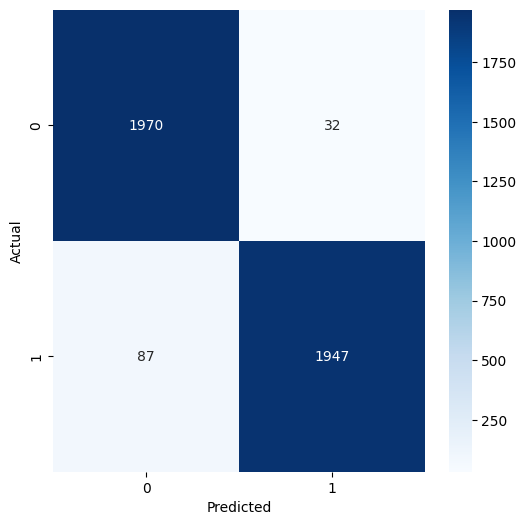

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(os.path.join(OUTPUT_PATH, "confusion_matrix.png"))
plt.show()

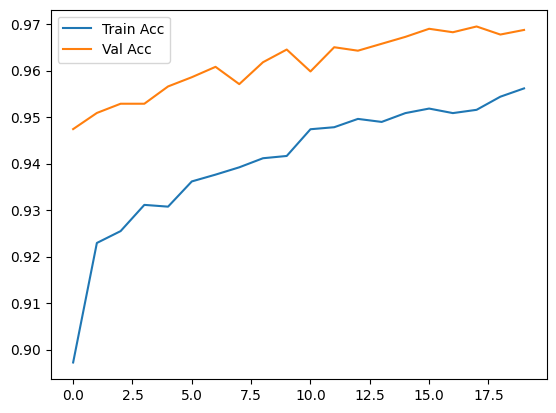

In [17]:
df = pd.read_csv(os.path.join(OUTPUT_PATH, "training_log.csv"))

plt.plot(df["train_acc"], label="Train Acc")
plt.plot(df["val_acc"], label="Val Acc")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "accuracy_plot.png"))
plt.show()

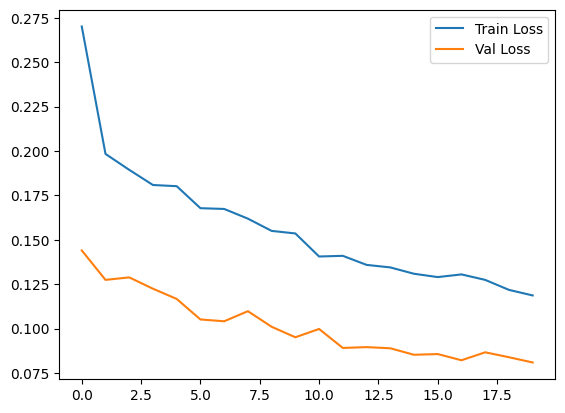

In [18]:
plt.plot(df["train_loss"], label="Train Loss")
plt.plot(df["val_loss"], label="Val Loss")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "loss_plot.png"))
plt.show()

In [19]:
import numpy as np

model.eval()

y_true = []
y_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = outputs.cpu().numpy()

        y_probs.extend(probs.flatten())
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)

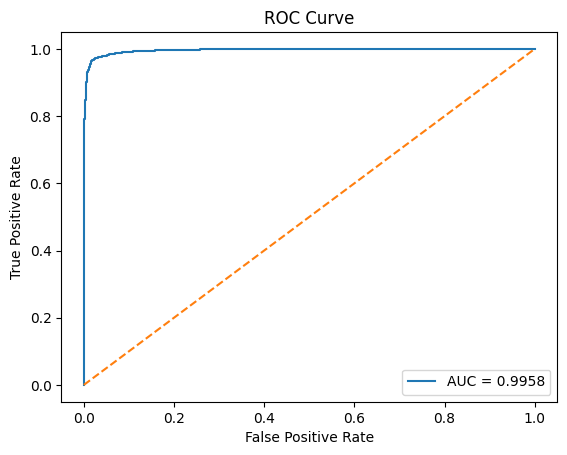

In [20]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "roc_curve.png"))
plt.show()

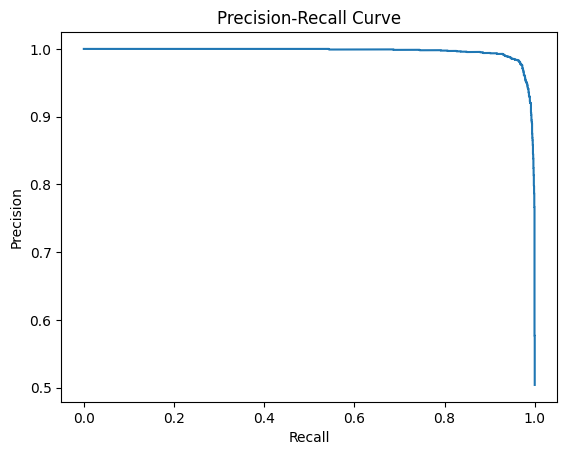

In [21]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.savefig(os.path.join(OUTPUT_PATH, "pr_curve.png"))
plt.show()

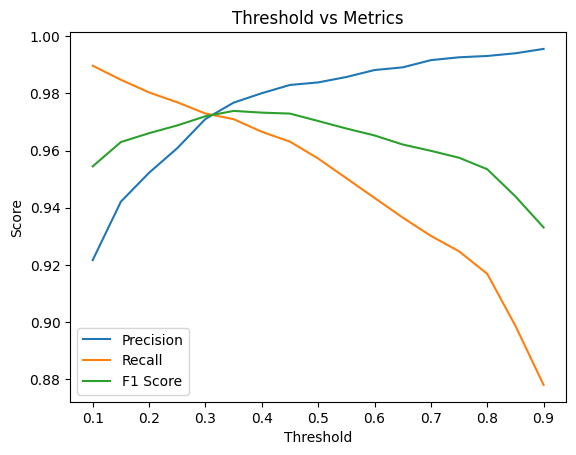

In [22]:
thresholds = np.arange(0.1, 0.95, 0.05)

precision_list = []
recall_list = []
f1_list = []

from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresholds:
    preds = (y_probs > t).astype(int)

    precision_list.append(precision_score(y_true, preds))
    recall_list.append(recall_score(y_true, preds))
    f1_list.append(f1_score(y_true, preds))

plt.figure()
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "threshold_metrics.png"))
plt.show()

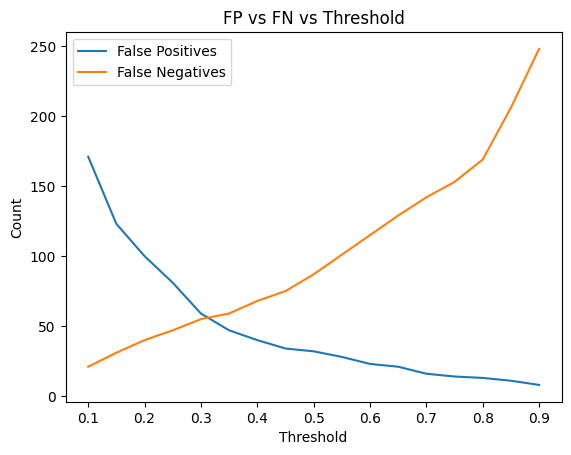

In [23]:
from sklearn.metrics import confusion_matrix

fp_list = []
fn_list = []

for t in thresholds:
    preds = (y_probs > t).astype(int)
    cm = confusion_matrix(y_true, preds)

    tn, fp, fn, tp = cm.ravel()

    fp_list.append(fp)
    fn_list.append(fn)

plt.figure()
plt.plot(thresholds, fp_list, label="False Positives")
plt.plot(thresholds, fn_list, label="False Negatives")

plt.xlabel("Threshold")
plt.ylabel("Count")
plt.title("FP vs FN vs Threshold")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "fp_fn_curve.png"))
plt.show()

In [24]:
#============================THRESHOLD ANALYSIS PHASE================================================

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

threshold = 0.65

y_pred_065 = (y_probs > threshold).astype(int)

# Confusion Matrix
cm_065 = confusion_matrix(y_true, y_pred_065)
print("Confusion Matrix (Threshold = 0.65):")
print(cm_065)

# Classification Report
report_065 = classification_report(y_true, y_pred_065)
print("\nClassification Report (Threshold = 0.65):\n", report_065)

# Save
with open(os.path.join(OUTPUT_PATH, "report_threshold_065.txt"), "w") as f:
    f.write(report_065)

Confusion Matrix (Threshold = 0.65):
[[1981   21]
 [ 129 1905]]

Classification Report (Threshold = 0.65):
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      2002
           1       0.99      0.94      0.96      2034

    accuracy                           0.96      4036
   macro avg       0.96      0.96      0.96      4036
weighted avg       0.96      0.96      0.96      4036



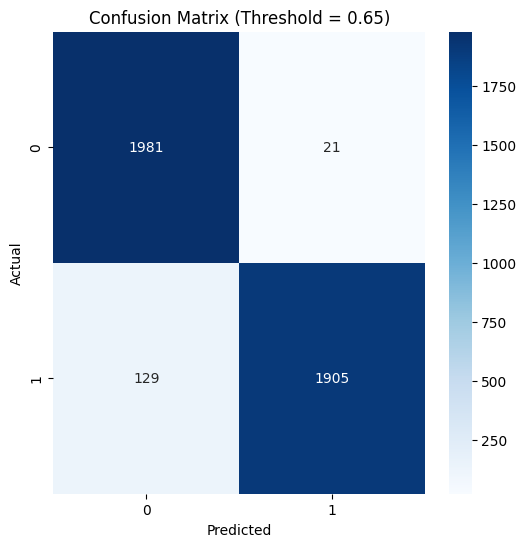

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(cm_065, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Threshold = 0.65)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(os.path.join(OUTPUT_PATH, "cm_065.png"))
plt.show()

In [27]:
import numpy as np

threshold_multi = 0.35
window_size = 3   # simulate 3-frame logic

y_pred_multi = []

for i in range(len(y_probs)):
    start = max(0, i - window_size + 1)
    window = y_probs[start:i+1]

    avg_prob = np.mean(window)

    if avg_prob > threshold_multi:
        y_pred_multi.append(1)
    else:
        y_pred_multi.append(0)

y_pred_multi = np.array(y_pred_multi)

In [28]:
cm_multi = confusion_matrix(y_true, y_pred_multi)
print("Confusion Matrix (Multi-frame 0.35):")
print(cm_multi)

report_multi = classification_report(y_true, y_pred_multi)
print("\nClassification Report (Multi-frame 0.35):\n", report_multi)

# Save
with open(os.path.join(OUTPUT_PATH, "report_multiframe_035.txt"), "w") as f:
    f.write(report_multi)

Confusion Matrix (Multi-frame 0.35):
[[1981   21]
 [   8 2026]]

Classification Report (Multi-frame 0.35):
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      2002
           1       0.99      1.00      0.99      2034

    accuracy                           0.99      4036
   macro avg       0.99      0.99      0.99      4036
weighted avg       0.99      0.99      0.99      4036



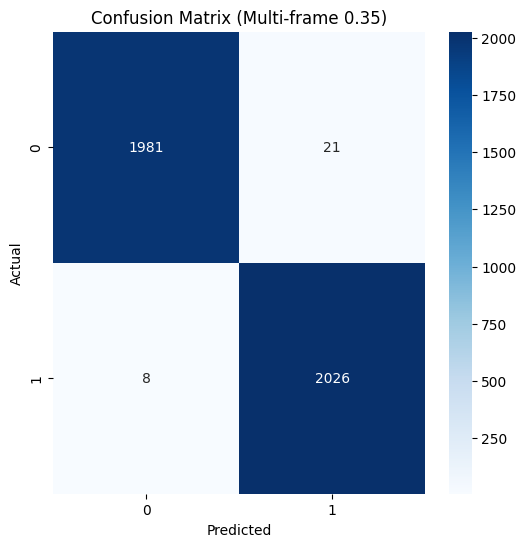

In [29]:
plt.figure(figsize=(6,6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Multi-frame 0.35)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(os.path.join(OUTPUT_PATH, "cm_multiframe_035.png"))
plt.show()

In [30]:
def extract_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    return tn, fp, fn, tp

tn_old, fp_old, fn_old, tp_old = extract_metrics(cm)
tn_065, fp_065, fn_065, tp_065 = extract_metrics(cm_065)
tn_m, fp_m, fn_m, tp_m = extract_metrics(cm_multi)

import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["TN", "FP", "FN", "TP"],
    "Default(0.5)": [tn_old, fp_old, fn_old, tp_old],
    "Single(0.65)": [tn_065, fp_065, fn_065, tp_065],
    "Multi(0.35)": [tn_m, fp_m, fn_m, tp_m]
})

print(comparison)

comparison.to_csv(os.path.join(OUTPUT_PATH, "threshold_comparison.csv"), index=False)

  Metric  Default(0.5)  Single(0.65)  Multi(0.35)
0     TN          1994          1981         1981
1     FP             8            21           21
2     FN           248           129            8
3     TP          1786          1905         2026


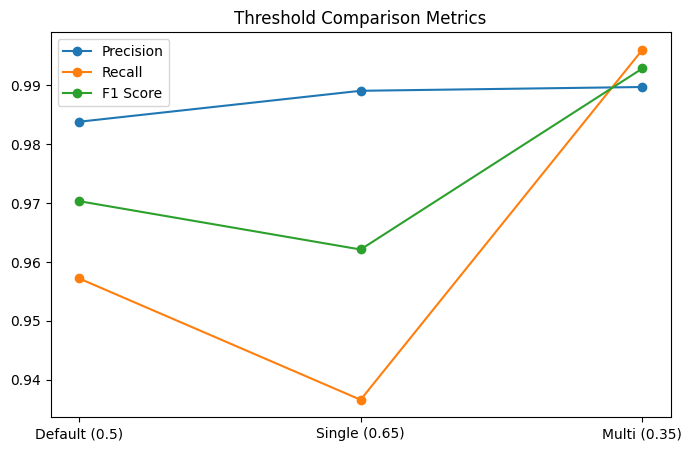

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return (
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    )

p_old, r_old, f1_old = get_metrics(y_true, y_pred)
p_065, r_065, f1_065 = get_metrics(y_true, y_pred_065)
p_m, r_m, f1_m = get_metrics(y_true, y_pred_multi)

labels = ["Default (0.5)", "Single (0.65)", "Multi (0.35)"]

precision_vals = [p_old, p_065, p_m]
recall_vals = [r_old, r_065, r_m]
f1_vals = [f1_old, f1_065, f1_m]

x = range(len(labels))

plt.figure(figsize=(8,5))
plt.plot(x, precision_vals, marker='o', label="Precision")
plt.plot(x, recall_vals, marker='o', label="Recall")
plt.plot(x, f1_vals, marker='o', label="F1 Score")

plt.xticks(x, labels)
plt.title("Threshold Comparison Metrics")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "threshold_comparison_metrics.png"))
plt.show()

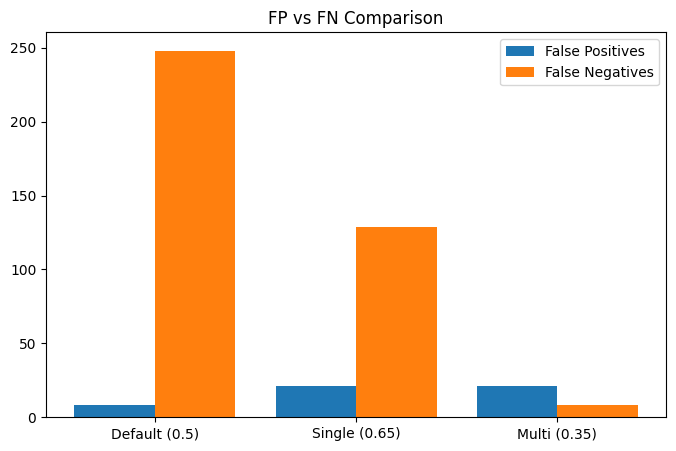

In [32]:
import numpy as np

fp_vals = [fp_old, fp_065, fp_m]
fn_vals = [fn_old, fn_065, fn_m]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, fp_vals, width=0.4, label="False Positives")
plt.bar(x + 0.2, fn_vals, width=0.4, label="False Negatives")

plt.xticks(x, labels)
plt.title("FP vs FN Comparison")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "fp_fn_comparison.png"))
plt.show()

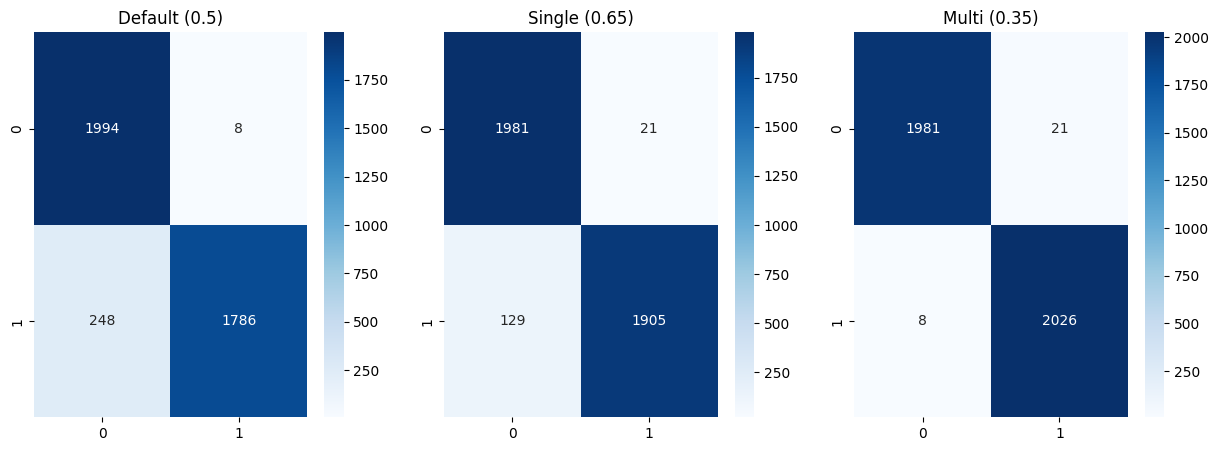

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Default (0.5)")

sns.heatmap(cm_065, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Single (0.65)")

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title("Multi (0.35)")

plt.savefig(os.path.join(OUTPUT_PATH, "cm_comparison.png"))
plt.show()

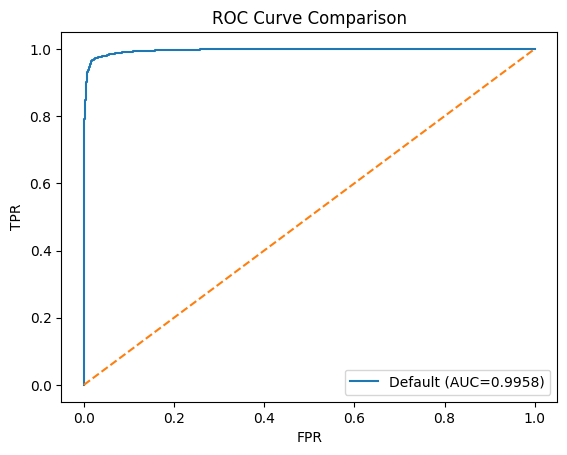

In [34]:
from sklearn.metrics import roc_curve, auc

def plot_roc(y_true, y_probs, label):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.4f})")

plt.figure()

plot_roc(y_true, y_probs, "Default")

# For threshold cases, reuse same probs (ROC unaffected by threshold)
# So just show once OR mention in paper

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "roc_comparison.png"))
plt.show()

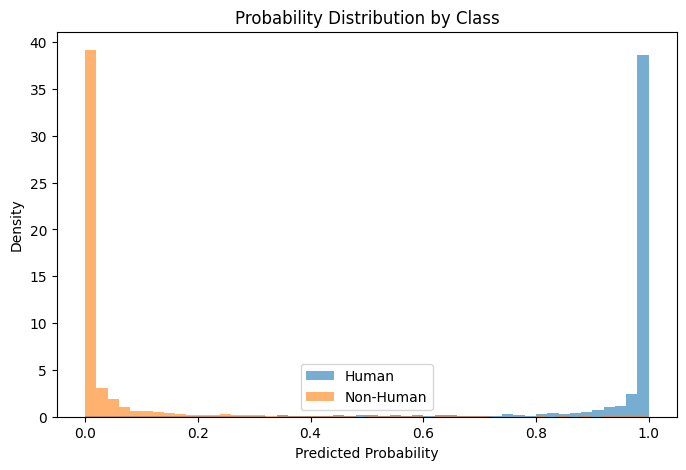

In [35]:
import matplotlib.pyplot as plt

human_probs = y_probs[y_true == 1]
nonhuman_probs = y_probs[y_true == 0]

plt.figure(figsize=(8,5))

plt.hist(human_probs, bins=50, alpha=0.6, label="Human", density=True)
plt.hist(nonhuman_probs, bins=50, alpha=0.6, label="Non-Human", density=True)

plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Probability Distribution by Class")
plt.legend()

plt.savefig(os.path.join(OUTPUT_PATH, "prob_distribution.png"))
plt.show()

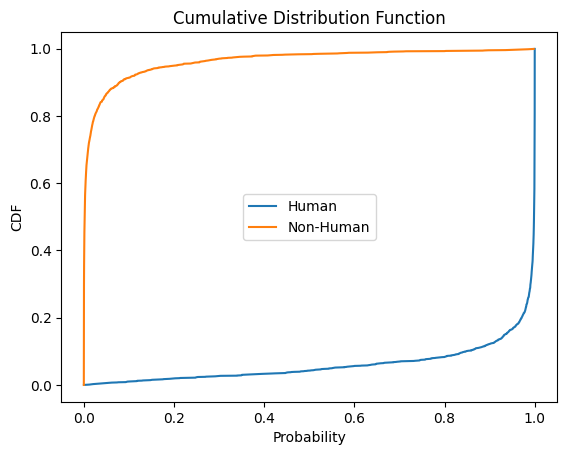

In [36]:
import numpy as np

def plot_cdf(data, label):
    sorted_data = np.sort(data)
    yvals = np.arange(len(sorted_data)) / float(len(sorted_data))
    plt.plot(sorted_data, yvals, label=label)

plt.figure()

plot_cdf(human_probs, "Human")
plot_cdf(nonhuman_probs, "Non-Human")

plt.xlabel("Probability")
plt.ylabel("CDF")
plt.title("Cumulative Distribution Function")

plt.legend()
plt.savefig(os.path.join(OUTPUT_PATH, "cdf_curve.png"))
plt.show()

In [37]:
import time

model.eval()

times = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)

        start = time.time()
        _ = model(images)
        end = time.time()

        times.append(end - start)

avg_time = sum(times) / len(times)

print("Average inference time per batch:", avg_time)
print("Approx per image:", avg_time / BATCH_SIZE)

Average inference time per batch: 0.011516125305839207
Approx per image: 0.0007197578316149504


In [3]:
from torchvision import datasets

BASE_PATH = r"D:\Code Lab\Projects\Mini Projects\Mini Project SE\AstraVision\ML\Dataset\FINAL_DATASET"

train_dataset = datasets.ImageFolder(BASE_PATH + "/train")

print(train_dataset.class_to_idx)

{'human': 0, 'non_human': 1}
